In [34]:
import pandas as pd

Read the Dataset

In [35]:
movies = pd.read_csv(r'D:\FSDS\IMDB Movie Rating Analysis\archive\movie.csv')

In [36]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [37]:
movies.shape

(27278, 3)

In [38]:
ratings =  pd.read_csv(r'D:\FSDS\IMDB Movie Rating Analysis\archive\rating.csv')

In [39]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40


In [40]:
ratings.shape

(20000263, 4)

In [41]:
tags = pd.read_csv(r'D:\FSDS\IMDB Movie Rating Analysis\archive\tag.csv')

In [42]:
tags.shape

(465564, 4)

In [43]:
tags.columns

Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='object')

In [44]:
ratings.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')

In [45]:
#For current analysis, we will remove timestamp
del ratings['timestamp']
del tags['timestamp']

In [46]:
tags.columns

Index(['userId', 'movieId', 'tag'], dtype='object')

In [47]:
ratings.columns

Index(['userId', 'movieId', 'rating'], dtype='object')

In [48]:
tags.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [49]:
tags.iloc[2]

userId            65
movieId          353
tag        dark hero
Name: 2, dtype: object

Data Structures

In [50]:
row_0 = tags.iloc[0]
type(row_0)

pandas.core.series.Series

In [51]:
print(row_0)

userId              18
movieId           4141
tag        Mark Waters
Name: 0, dtype: object


In [52]:
row_0.index

Index(['userId', 'movieId', 'tag'], dtype='object')

In [53]:
row_0['userId']

18

In [54]:
'rating' in row_0

False

In [55]:
row_0.name

0

In [56]:
row_0 = row_0.rename('firstrow')
row_0.name

'firstrow'

In [57]:
tags.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


DataFrames

In [58]:
tags.head()

,userId,movieId,tag
0,18,4141,Mark Waters
1,65,208,dark hero
2,65,353,dark hero
3,65,521,noir thriller
4,65,592,dark hero


In [59]:
tags.index

RangeIndex(start=0, stop=465564, step=1)

In [60]:
tags.columns

Index(['userId', 'movieId', 'tag'], dtype='object')

In [62]:
tags.iloc[ [0, 11, 500] ]

,userId,movieId,tag
0,18,4141,Mark Waters
11,65,1783,noir thriller
500,342,55908,entirely dialogue


Descriptive Stastics

In [65]:
ratings['rating'].describe()

count    2.000026e+07
mean     3.525529e+00
std      1.051989e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [66]:
ratings.describe()

,userId,movieId,rating
count,2.000026e+07,2.000026e+07,2.000026e+07
mean,6.904587e+04,9.041567e+03,3.525529e+00
std,4.003863e+04,1.978948e+04,1.051989e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,3.439500e+04,9.020000e+02,3.000000e+00
50%,6.914100e+04,2.167000e+03,3.500000e+00
75%,1.036370e+05,4.770000e+03,4.000000e+00
max,1.384930e+05,1.312620e+05,5.000000e+00


In [67]:
ratings['rating'].mean()

3.5255285642993797

In [68]:
ratings.mean()

userId     69045.872583
movieId     9041.567330
rating         3.525529
dtype: float64

In [69]:
ratings['rating'].min()

0.5

In [70]:
ratings['rating'].max()

5.0

In [71]:
ratings['rating'].std()

1.051988919275684

In [72]:
ratings['rating'].mode()

0    4.0
Name: rating, dtype: float64

In [73]:
filter1 = ratings['rating'] > 10
print(filter1)
filter1.any()

0           False
1           False
2           False
3           False
4           False
            ...  
20000258    False
20000259    False
20000260    False
20000261    False
20000262    False
Name: rating, Length: 20000263, dtype: bool


False

In [74]:
filter2 = ratings['rating'] > 0
filter2.all()

True

Data Cleaning : Handling Missing Data

In [76]:
movies.shape

(27278, 3)

In [78]:
movies.isnull().any().any()

False

In [80]:
ratings.shape

(20000263, 3)

In [82]:
ratings.isnull().any().any()

False

In [83]:
tags.shape

(465564, 3)

In [84]:
tags.isnull().any().any()

True

In [85]:
tags = tags.dropna()

In [86]:
tags.isnull().any().any()

False

Data Visulaization

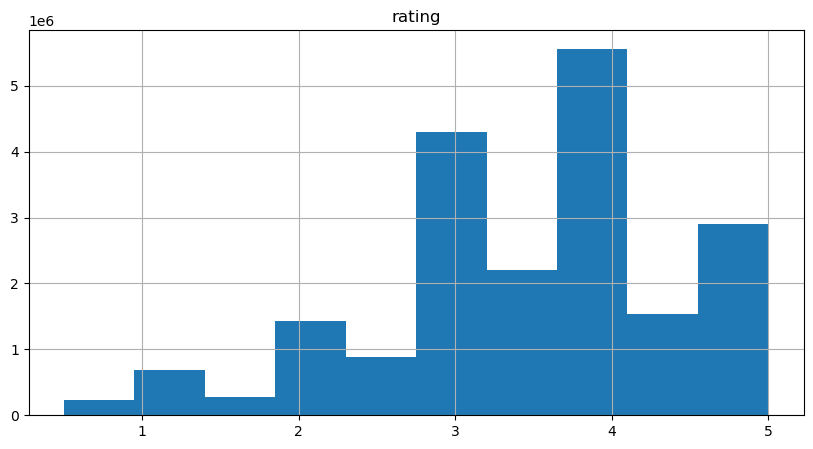

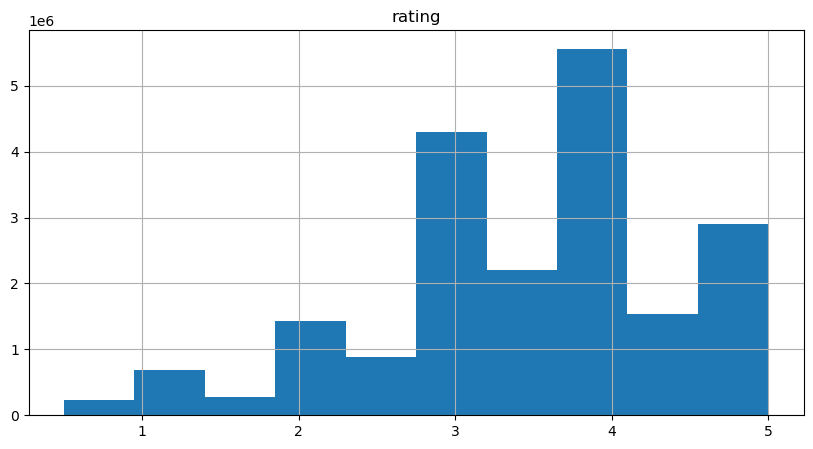

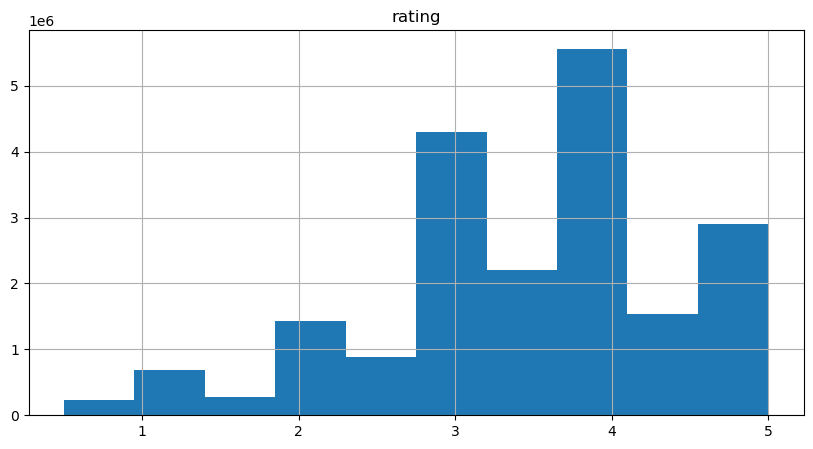

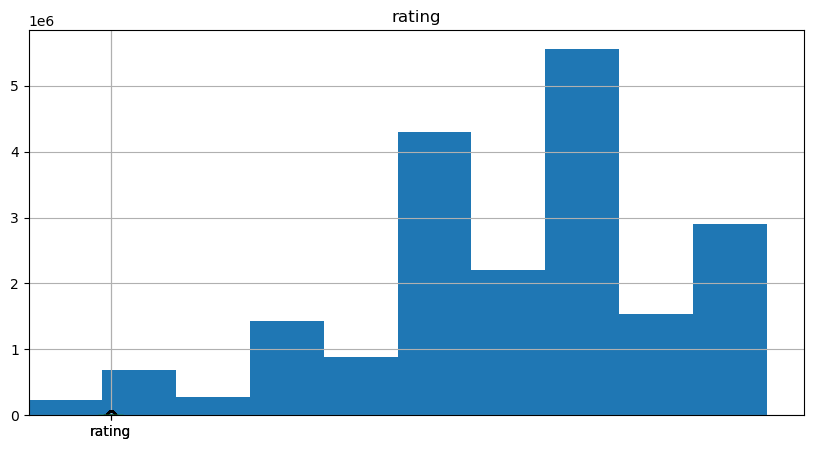

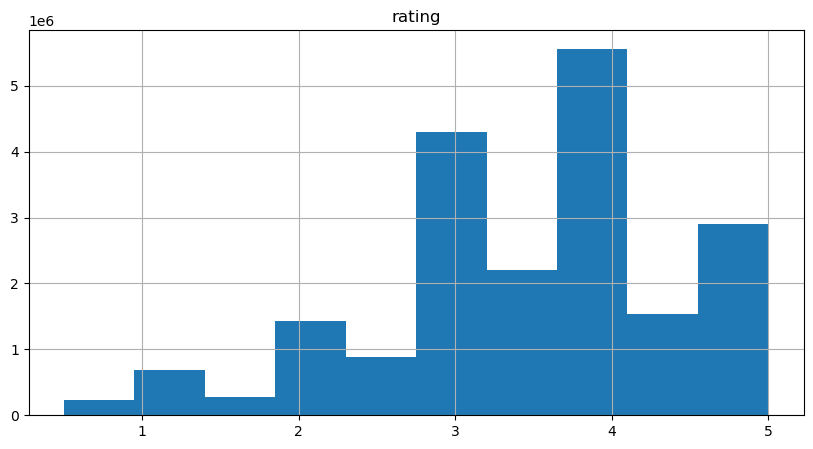

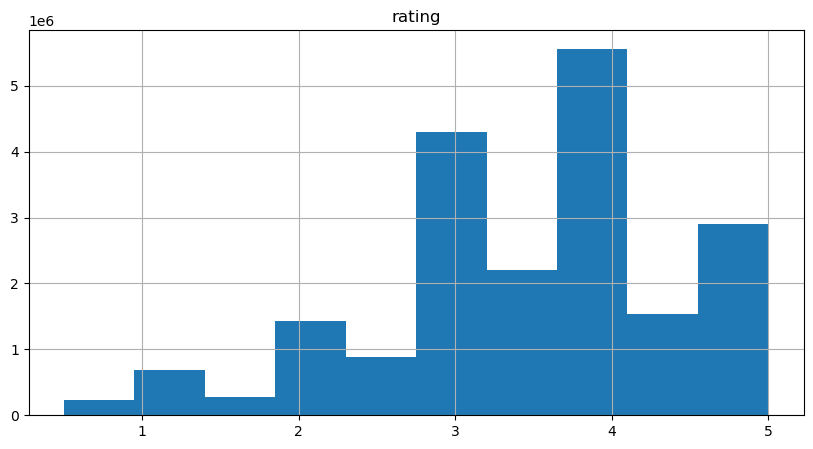

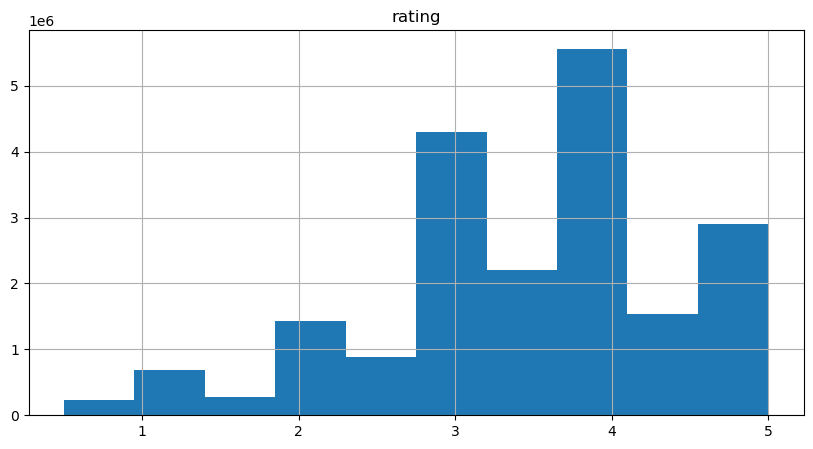

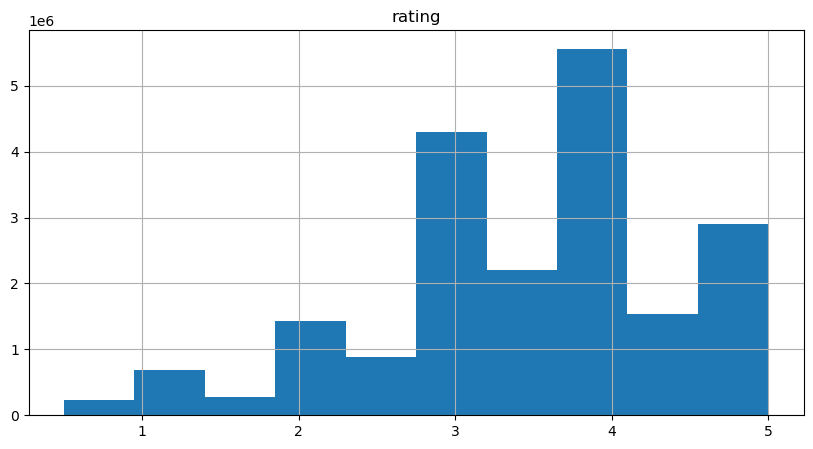

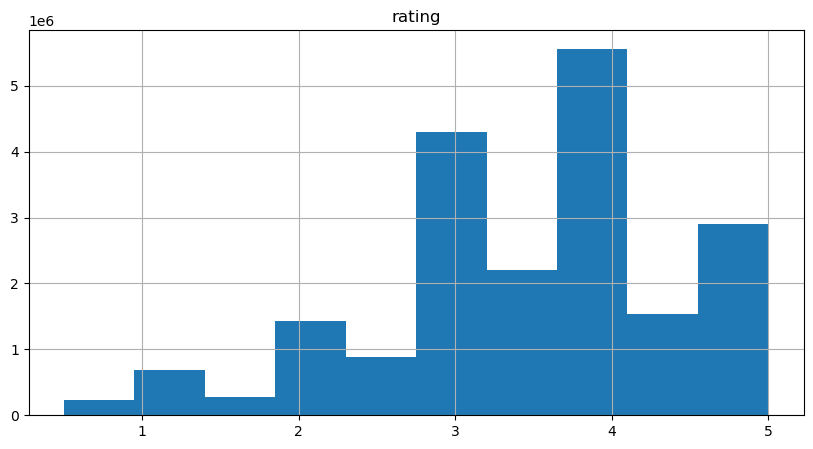

In [98]:
import matplotlib.pyplot as plt 


ratings.hist(column = 'rating', figsize = (10,5))
plt.show()

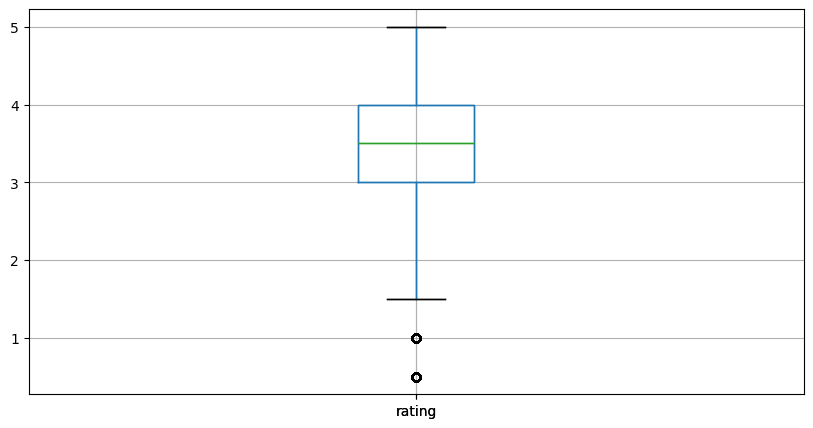

In [100]:
ratings.boxplot(column = 'rating', figsize = (10,5))
plt.show()

Slicing Out Columns

In [101]:
tags['tag'].head()

0      Mark Waters
1        dark hero
2        dark hero
3    noir thriller
4        dark hero
Name: tag, dtype: object

In [103]:
movies[['title','genres']].head()

,title,genres
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,Jumanji (1995),Adventure|Children|Fantasy
2,Grumpier Old Men (1995),Comedy|Romance
3,Waiting to Exhale (1995),Comedy|Drama|Romance
4,Father of the Bride Part II (1995),Comedy


In [104]:
ratings[-10:]

,userId,movieId,rating
20000253,138493,60816,4.5
20000254,138493,61160,4.0
20000255,138493,65682,4.5
20000256,138493,66762,4.5
20000257,138493,68319,4.5
20000258,138493,68954,4.5
20000259,138493,69526,4.5
20000260,138493,69644,3.0
20000261,138493,70286,5.0
20000262,138493,71619,2.5


In [106]:
tag_counts = tags['tag'].value_counts()
tag_counts[-10:]

tag
missing child                    1
Ron Moore                        1
Citizen Kane                     1
mullet                           1
biker gang                       1
Paul Adelstein                   1
the wig                          1
killer fish                      1
genetically modified monsters    1
topless scene                    1
Name: count, dtype: int64

In [110]:
tag_counts[:-10].plot(kind='bar', figsize=(10,5))

<Axes: xlabel='tag'>

C:\Users\manns\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\manns\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\manns\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 143 (\x8f) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\manns\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\manns\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
